# 岭回归、Lasso 与 ElasticNet

正则化通过惩罚过大的系数来控制模型复杂度。Ridge 使用 L2 惩罚；Lasso 使用 L1 惩罚并可能把部分系数压到 0；ElasticNet 同时使用两者。

**建议学习方法：** 从上到下逐格运行；先观察输出，再修改参数并重新运行。代码固定了随机种子，便于复现实验结果。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 中文字体设置：按顺序尝试本机字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)


In [2]:
# ========== 1. 加载糖尿病回归数据 ==========
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

data = load_diabetes(as_frame=True)
X, y = data.data, data.target
print('数据形状:', X.shape)
print(X.head())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


数据形状: (442, 10)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


In [6]:
# ========== 2. 用 Pipeline 建立四种回归模型 ==========
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    '普通线性回归': LinearRegression(),
    'Ridge': Ridge(alpha=10.0),
    'Lasso': Lasso(alpha=1.0, max_iter=10000), #优化算法允许进行的最大迭代次数是 10000 次
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
    #alpha=0.1控制的是：“罚多重”  l1_ratio=0.5控制的是：“这份惩罚里，L1 和 L2 怎么分配”
}

fitted_models = {}
rows = []
for name, estimator in models.items(): #字典.items() ：同时把字典里面的「键」和「值」拿出来。
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', estimator)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    fitted_models[name] = pipe
    rows.append({
        '模型': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R²': r2_score(y_test, pred)
    })

result_df = pd.DataFrame(rows).sort_values('RMSE') #按照 RMSE 这一列进行排序 升序。
print(result_df.round(4))
print(fitted_models)

           模型      MAE     RMSE      R²
2       Lasso  42.8030  53.1467  0.4669
3  ElasticNet  42.8733  53.5393  0.4590
1       Ridge  42.8568  53.6263  0.4572
0      普通线性回归  42.7941  53.8534  0.4526
{'普通线性回归': Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())]), 'Ridge': Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))]), 'Lasso': Pipeline(steps=[('scaler', StandardScaler()), ('model', Lasso(max_iter=10000))]), 'ElasticNet': Pipeline(steps=[('scaler', StandardScaler()),
                ('model', ElasticNet(alpha=0.1, max_iter=10000))])}


     普通线性回归   Ridge   Lasso  ElasticNet
age   1.754   1.931   0.687       1.902
sex -11.512 -11.028  -9.298     -10.623
bmi  25.607  25.606  26.219      25.236
bp   16.829  16.304  15.657      16.000
s1  -44.449 -12.934  -8.228      -8.893
s2   24.641   0.538  -0.000      -2.079
s3    7.677  -6.125  -9.024      -7.816
s4   13.139   8.569   3.421       7.708
s5   35.161  22.749  22.636      20.998
s6    2.351   2.918   2.099       3.152

Lasso 中被压到接近 0 的系数数目: 1


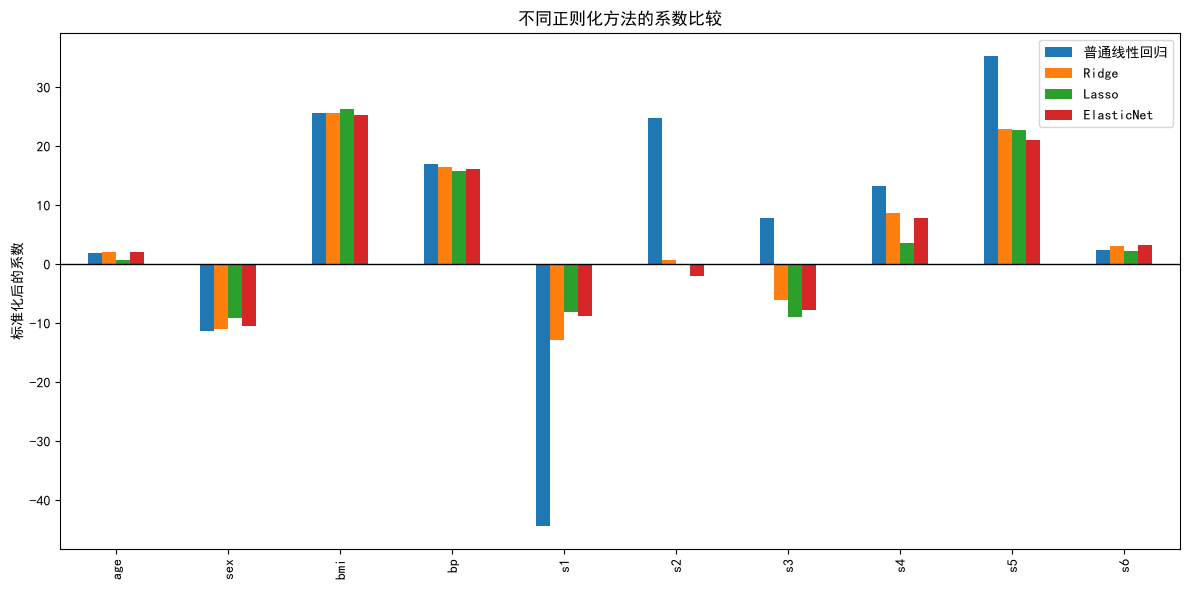

In [15]:
# ========== 3. 比较标准化空间中的模型系数 ==========
coef_df = pd.DataFrame(index=X.columns)#暂时没有数据列，把行索引设成原始数据的所有特征名
#print(coef_df)
for name, pipe in fitted_models.items():
    coef_df[name] = pipe.named_steps['model'].coef_ #拿到当前模型训练得到的每个特征对应的系数
#pipe.named_steps['model']从 Pipeline 取出名字叫 'model' 模型；.coef_取出这个模型训练得到的系数
print(coef_df.round(3))
print('\nLasso 中被压到接近 0 的系数数目:',
      int((np.abs(coef_df['Lasso']) < 1e-8).sum()))#.abs() 取绝对值。

coef_df.plot(kind='bar', figsize=(12, 6))#bar是柱状图，pandas 画柱状图时，默认会把 DataFrame 的 index 当作横轴标签。
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('标准化后的系数')
plt.title('不同正则化方法的系数比较')
plt.tight_layout() #动调整图里面各元素之间的间距
plt.show()


In [22]:
# ========== 4. 观察 Ridge 的 alpha 如何影响系数 ==========
alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge_rows = []
for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha))
    ])
    pipe.fit(X_train, y_train)
    print(pipe.named_steps['model'].coef_)
    pred = pipe.predict(X_test)
    ridge_rows.append({
        'alpha': alpha,
        '测试集 RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        '系数绝对值之和': np.abs(pipe.named_steps['model'].coef_).sum()
    })

ridge_df = pd.DataFrame(ridge_rows)
print(ridge_df.round(4))


[  1.75445444 -11.51110924  25.60894398  16.82774155 -44.32152931
  24.54196146   7.62086133  13.1209677   35.1120264    2.35264791]
[  1.76053729 -11.50488363  25.62469304  16.81778273 -43.20966186
  23.67767588   7.13085007  12.96531191  34.68257943   2.36395728]
[  1.80734179 -11.44818951  25.73269892  16.73429974 -34.67195409
  17.05307485   3.36991411  11.76426044  31.3783838    2.45813922]
[  1.9313315  -11.02819247  25.60556062  16.30419091 -12.93423623
   0.53817343  -6.1251089    8.56948441  22.74930836   2.9181459 ]
[ 2.09378937 -8.16807633 21.56193611 13.92691696 -2.89826229 -4.08719681
 -9.05933867  6.68386739 16.47722222  4.6888156 ]
[ 1.91919589 -1.57646388  9.14961765  6.39177237  0.89757111  0.03201698
 -4.96835395  4.5193401   7.51914174  4.37305065]
     alpha  测试集 RMSE   系数绝对值之和
0     0.01   53.8523  182.7722
1     0.10   53.8429  179.7379
2     1.00   53.7775  156.4183
3    10.00   53.6263  108.7037
4   100.00   53.4624   89.6454
5  1000.00   58.7513   41.3465


**关键结论：** `alpha` 越大，惩罚越强，系数通常越小；但惩罚过强会造成欠拟合。实际项目中应使用交叉验证选择 `alpha`。
